# DL Série temporelle – Prix au m² (LSTM TensorFlow)

Modèle de prévision séquentielle sur les prix par commune.

- **Grain** : commune × mois (direct depuis `rpt_features_commune_mois`)
- **Cible** : `prix_m2_med` à t+1, t+2, t+3 (horizon 3 mois)
- **Architecture** : LSTM bidirectionnel (TensorFlow / Keras)
- **Fenêtre glissante** : 12 mois d'historique → prédit les 3 mois suivants
- **Split** : train 2022-2023 / validation 2024 / test 2025

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import clickhouse_connect
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from dotenv import load_dotenv

warnings.filterwarnings('ignore')
load_dotenv()

print(f'TensorFlow {tf.__version__}')

client = clickhouse_connect.get_client(
    host=os.getenv('CLICKHOUSE_HOST', 'localhost'),
    port=int(os.getenv('CLICKHOUSE_PORT', 8123)),
    username=os.getenv('CLICKHOUSE_USER', 'admin'),
    password=os.getenv('CLICKHOUSE_PASSWORD', ''),
)
print('ClickHouse connecté')

TensorFlow 2.21.0
ClickHouse connecté


## 1. Chargement au niveau commune

In [2]:
query = """
SELECT
    code_commune,
    code_departement,
    annee,
    mois,
    -- cible
    prix_m2_med,
    -- volume
    nb_transactions,
    -- caractéristiques du parc
    pct_appt,
    pct_maison,
    surface_moy,
    nb_pieces_moy,
    -- DPE
    pct_passoires_thermiques,
    conso_ep_moy,
    -- construction
    nb_commences,
    taux_concretisation,
    -- logement social
    nb_entrees_ls,
    -- marché neuf
    prix_m2_neuf_moy,
    delai_ecoulement_moy,
    -- lags & rolling
    prix_m2_lag_1m,
    prix_m2_lag_3m,
    prix_m2_lag_6m,
    prix_m2_lag_12m,
    prix_m2_roll3m,
    prix_m2_roll6m,
    prix_m2_roll12m,
    evol_1m_pct,
    evol_12m_pct,
    -- encodage cyclique
    mois_sin,
    mois_cos
FROM db_ai_house.rpt_features_commune_mois
WHERE prix_m2_med > 0
  AND prix_m2_lag_12m IS NOT NULL
ORDER BY annee, mois, code_commune
"""

df = client.query_df(query)
# annee/mois arrivent en uint16/uint8 depuis ClickHouse — cast en int32 avant calcul
# pour éviter l'overflow (uint16: 2022*100 = 5492 au lieu de 202200)
df['periode'] = df['annee'].astype('int32') * 100 + df['mois'].astype('int32')
print(f'{len(df):,} lignes | {df["code_commune"].nunique():,} communes | {df["annee"].min()}–{df["annee"].max()}')
df.head(3)

386,433 lignes | 17,632 communes | 2022–2025


,code_commune,code_departement,annee,mois,prix_m2_med,nb_transactions,pct_appt,pct_maison,surface_moy,nb_pieces_moy,...,prix_m2_lag_6m,prix_m2_lag_12m,prix_m2_roll3m,prix_m2_roll6m,prix_m2_roll12m,evol_1m_pct,evol_12m_pct,mois_sin,mois_cos,periode
0,01004,01,2022,1,3122.66,8,87.5,12.5,63.1,3.0,...,2487.79,2249.70,3295.16,3256.56,2749.53,10.05,24.15,0.5,0.866025,202201
1,01033,01,2022,1,1908.43,7,71.4,28.6,91.3,4.0,...,2909.72,2355.91,1990.07,2295.49,2472.16,-5.34,-17.95,0.5,0.866025,202201
2,01034,01,2022,1,1750.00,9,66.7,11.1,73.2,2.3,...,2090.43,1208.14,3842.75,3054.66,2613.03,312.37,460.27,0.5,0.866025,202201


## 2. Construction des séquences (fenêtre glissante)

In [3]:
LOOKBACK = 12   # données dispo à partir de 2022 → 24 mois train max, LOOKBACK 24 impossible
HORIZON  = 3

FEATURES = [
    'prix_m2_med',
    'nb_transactions',
    'pct_appt', 'pct_maison', 'surface_moy', 'nb_pieces_moy',
    'pct_passoires_thermiques', 'conso_ep_moy',
    'nb_commences', 'taux_concretisation', 'nb_entrees_ls',
    'prix_m2_neuf_moy', 'delai_ecoulement_moy',
    'prix_m2_lag_1m', 'prix_m2_lag_3m', 'prix_m2_lag_6m', 'prix_m2_lag_12m',
    'prix_m2_roll3m', 'prix_m2_roll6m', 'prix_m2_roll12m',
    'evol_1m_pct', 'evol_12m_pct',
    'mois_sin', 'mois_cos',
]

TARGET_COL = 'prix_m2_med'
TARGET_IDX = FEATURES.index(TARGET_COL)


def fill_monthly_grid(raw, commune):
    # Filtre lignes avec annee/mois invalides (données corrompues)
    raw = raw[(raw['mois'].between(1, 12)) & (raw['annee'] > 2000)].copy()
    if raw.empty:
        return raw
    raw = raw.sort_values('periode')
    a, m     = int(raw.iloc[0]['annee']),  int(raw.iloc[0]['mois'])
    a_end, m_end = int(raw.iloc[-1]['annee']), int(raw.iloc[-1]['mois'])
    rows = []
    while (a, m) <= (a_end, m_end):
        rows.append((a, m, a * 100 + m))
        m += 1
        if m > 12:
            m = 1
            a += 1
    grid = pd.DataFrame(rows, columns=['annee', 'mois', 'periode'])
    grid['code_commune'] = commune
    merged = grid.merge(
        raw.drop(columns=['code_commune', 'annee', 'mois'], errors='ignore'),
        on='periode', how='left',
    )
    # ffill → bfill → fillna(0) : certaines features (DPE, construction, neuf)
    # sont NULL dans la source pour des communes sans données — on impute 0
    # plutôt que d'exclure la commune entière via dropna
    merged[FEATURES] = merged[FEATURES].ffill().bfill().fillna(0)
    return merged


def make_sequences(entity_df, scaler):
    data = scaler.transform(entity_df[FEATURES].values.astype(np.float32))
    X, y = [], []
    for i in range(LOOKBACK, len(data) - HORIZON + 1):
        X.append(data[i - LOOKBACK:i])
        y.append(data[i:i + HORIZON, TARGET_IDX])
    return np.array(X), np.array(y)


communes = sorted(df['code_commune'].unique())

train_years = [2022, 2023]   # données disponibles à partir de 2022
val_year    = 2024
test_year   = 2025

X_train_list, y_train_list = [], []
X_val_list,   y_val_list   = [], []
X_test_list,  y_test_list  = [], []
scalers = {}

for commune in communes:
    raw = df[df['code_commune'] == commune].sort_values('periode')
    if len(raw) < 12:
        continue

    commune_df = fill_monthly_grid(raw, commune)
    if len(commune_df) < LOOKBACK + HORIZON + 6:
        continue

    train_df = commune_df[commune_df['annee'].isin(train_years)]
    if len(train_df) < LOOKBACK + HORIZON:
        continue

    # Scaler fitté sur toutes les données d'entraînement (pré-2024) pour
    # couvrir la même distribution que celle passée à make_sequences
    all_train_df = commune_df[commune_df['annee'] <= train_years[-1]]
    scaler = StandardScaler()
    scaler.fit(all_train_df[FEATURES].values)
    scalers[commune] = scaler

    X, y = make_sequences(all_train_df, scaler)
    if len(X): X_train_list.append(X); y_train_list.append(y)

    val_df = commune_df[commune_df['annee'].isin(train_years[-1:] + [val_year])]
    Xv, yv = make_sequences(val_df, scaler)
    val_mask = val_df['annee'].values[LOOKBACK:len(val_df) - HORIZON + 1] == val_year
    if val_mask.any() and len(Xv):
        X_val_list.append(Xv[val_mask]); y_val_list.append(yv[val_mask])

    test_df = commune_df[commune_df['annee'].isin([val_year, test_year])]
    Xt, yt = make_sequences(test_df, scaler)
    test_mask = test_df['annee'].values[LOOKBACK:len(test_df) - HORIZON + 1] == test_year
    if test_mask.any() and len(Xt):
        X_test_list.append(Xt[test_mask]); y_test_list.append(yt[test_mask])

assert X_train_list, 'Aucune commune retenue — vérifier les filtres ou les données'

X_train = np.concatenate(X_train_list)
y_train = np.concatenate(y_train_list)
X_val   = np.concatenate(X_val_list)  if X_val_list  else np.empty((0, LOOKBACK, len(FEATURES)), np.float32)
y_val   = np.concatenate(y_val_list)  if y_val_list  else np.empty((0, HORIZON), np.float32)
X_test  = np.concatenate(X_test_list) if X_test_list else np.empty((0, LOOKBACK, len(FEATURES)), np.float32)
y_test  = np.concatenate(y_test_list) if y_test_list else np.empty((0, HORIZON), np.float32)

print(f'Communes retenues : {len(scalers):,}')
print(f'Train : X={X_train.shape}, y={y_train.shape}')
print(f'Val   : X={X_val.shape},   y={y_val.shape}')
print(f'Test  : X={X_test.shape},  y={y_test.shape}')

Communes retenues : 8,989
Train : X=(65798, 12, 24), y=(65798, 3)
Val   : X=(89861, 12, 24),   y=(89861, 3)
Test  : X=(86215, 12, 24),  y=(86215, 3)


## 3. Architecture LSTM bidirectionnel

In [4]:
n_features = X_train.shape[2]

inputs = keras.Input(shape=(LOOKBACK, n_features))
x = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(inputs)
x = layers.Dropout(0.2)(x)
x = layers.Bidirectional(layers.LSTM(64))(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(64, activation='relu')(x)
outputs = layers.Dense(HORIZON)(x)  # prédit HORIZON valeurs normalisées

model = keras.Model(inputs, outputs)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='mae',
    metrics=['mse'],
)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 12, 24)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 12, 256)        │       156,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 329,475 (1.26 MB)

 Trainable params: 329,475 (1.26 MB)

 Non-trainable params: 0 (0.00 B)

## 4. Entraînement

In [5]:
callbacks = [
    keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True, monitor='val_loss'),
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=7, min_lr=1e-5, monitor='val_loss'),
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=150,
    batch_size=256,
    callbacks=callbacks,
    verbose=1,
)

print(f'\nMeilleure val_loss : {min(history.history["val_loss"]):.4f}')

Epoch 1/150


  1/258 ━━━━━━━━━━━━━━━━━━━━ 10:15 2s/step - loss: 0.8121 - mse: 1.1173

  3/258 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - loss: 0.7847 - mse: 1.0625 

  5/258 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - loss: 0.7764 - mse: 1.0526

  7/258 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - loss: 0.7728 - mse: 1.0493

...

249/258 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.6221 - mse: 0.7761

252/258 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.6221 - mse: 0.7761

255/258 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.6221 - mse: 0.7761

258/258 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - loss: 0.6218 - mse: 0.7776 - val_loss: 1.2408 - val_mse: 23.6180 - learning_rate: 2.5000e-04



Meilleure val_loss : 1.0930


## 5. Courbes d'apprentissage

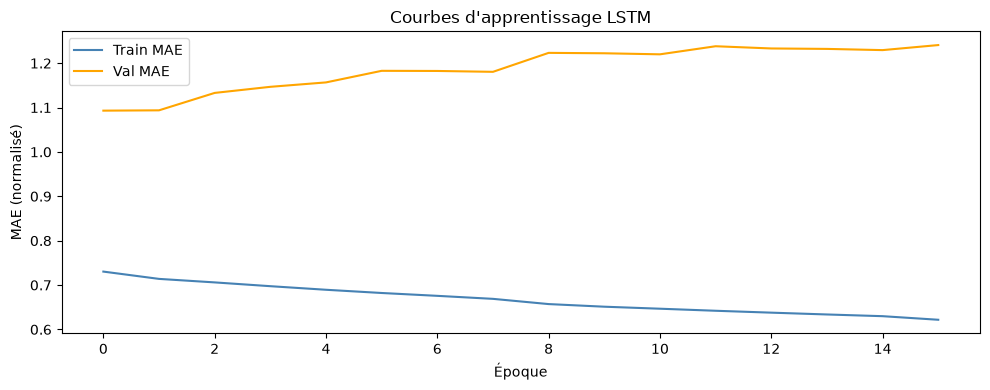

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history.history['loss'],     label='Train MAE', color='steelblue')
ax.plot(history.history['val_loss'], label='Val MAE',   color='orange')
ax.set_xlabel('Époque')
ax.set_ylabel('MAE (normalisé)')
ax.set_title("Courbes d'apprentissage LSTM")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Évaluation sur le jeu de test

In [7]:
y_pred_norm = model.predict(X_test)

# Dénormalisation : approximation globale via le scaler de la première commune
ref_scaler = list(scalers.values())[0]
scale = ref_scaler.scale_[TARGET_IDX]
mean  = ref_scaler.mean_[TARGET_IDX]

y_test_real = y_test * scale + mean
y_pred_real = y_pred_norm * scale + mean

mae_h  = [mean_absolute_error(y_test_real[:, h], y_pred_real[:, h]) for h in range(HORIZON)]
rmse_h = [np.sqrt(mean_squared_error(y_test_real[:, h], y_pred_real[:, h])) for h in range(HORIZON)]

print('Métriques par horizon (test 2025) :')
for h in range(HORIZON):
    print(f'  t+{h+1} : MAE={mae_h[h]:.0f} €/m²  |  RMSE={rmse_h[h]:.0f} €/m²')

print(f'\nMAE moyen (t+1 à t+{HORIZON}) : {np.mean(mae_h):.0f} €/m²')

   1/2695 ━━━━━━━━━━━━━━━━━━━━ 12:02 268ms/step

  19/2695 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step     

  39/2695 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step

  60/2695 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step

  81/2695 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step

...

2665/2695 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

2684/2695 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

2695/2695 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

2695/2695 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step


Métriques par horizon (test 2025) :
  t+1 : MAE=477 €/m²  |  RMSE=3266 €/m²
  t+2 : MAE=481 €/m²  |  RMSE=3116 €/m²
  t+3 : MAE=517 €/m²  |  RMSE=5215 €/m²

MAE moyen (t+1 à t+3) : 492 €/m²


## 7. Visualisation – prévision vs réel (t+1)

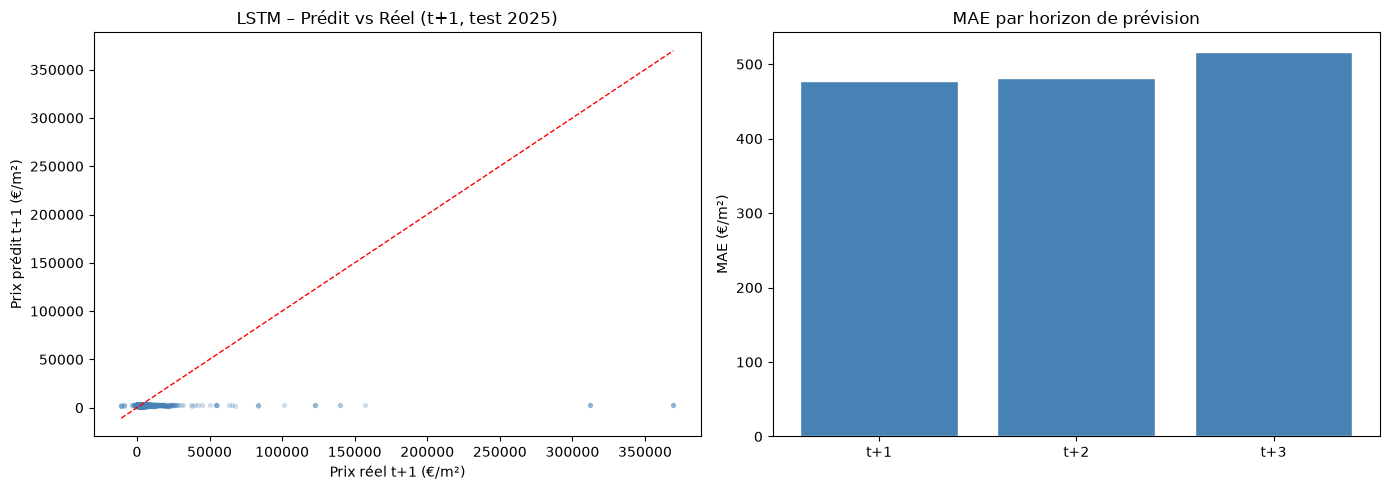

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter
ax = axes[0]
ax.scatter(y_test_real[:, 0], y_pred_real[:, 0], alpha=0.2, s=8, color='steelblue')
lim = (y_test_real[:, 0].min(), y_test_real[:, 0].max())
ax.plot(lim, lim, 'r--', lw=1)
ax.set_xlabel('Prix réel t+1 (€/m²)')
ax.set_ylabel('Prix prédit t+1 (€/m²)')
ax.set_title('LSTM – Prédit vs Réel (t+1, test 2025)')

# MAE par horizon
ax = axes[1]
ax.bar([f't+{h+1}' for h in range(HORIZON)], mae_h, color='steelblue', edgecolor='white')
ax.set_ylabel('MAE (€/m²)')
ax.set_title('MAE par horizon de prévision')

plt.tight_layout()
plt.show()

## 8. Résumé

In [9]:
print('=== RÉSULTATS LSTM (test 2025) ===')
print(f'Architecture  : BiLSTM 128 → BiLSTM 64 → Dense 64 → Dense {HORIZON}')
print(f'Fenêtre       : {LOOKBACK} mois → {HORIZON} mois')
print(f'Paramètres    : {model.count_params():,}')
print()
for h in range(HORIZON):
    print(f'  t+{h+1} → MAE = {mae_h[h]:.0f} €/m²   RMSE = {rmse_h[h]:.0f} €/m²')
print(f'\nMAE moyen : {np.mean(mae_h):.0f} €/m²')

=== RÉSULTATS LSTM (test 2025) ===
Architecture  : BiLSTM 128 → BiLSTM 64 → Dense 64 → Dense 3
Fenêtre       : 12 mois → 3 mois
Paramètres    : 329,475

  t+1 → MAE = 477 €/m²   RMSE = 3266 €/m²
  t+2 → MAE = 481 €/m²   RMSE = 3116 €/m²
  t+3 → MAE = 517 €/m²   RMSE = 5215 €/m²

MAE moyen : 492 €/m²
